# Yield curve plot

Plots government / benchmark **zero-coupon or par yields** by maturity (the classic “yield curve” picture).

**Data below** is typed in from your table dated **2026-03-27**. Update the arrays for another day or wire in a data source in a later cell.

A **CIR** affine bond curve (same \(\mathbb Q\) formulas as Question 6 in `term_project_v1`) is overlaid after the next section; adjust `KAPPA_Q` and `SIGMA` and re-run to see how sensitive the fit is.

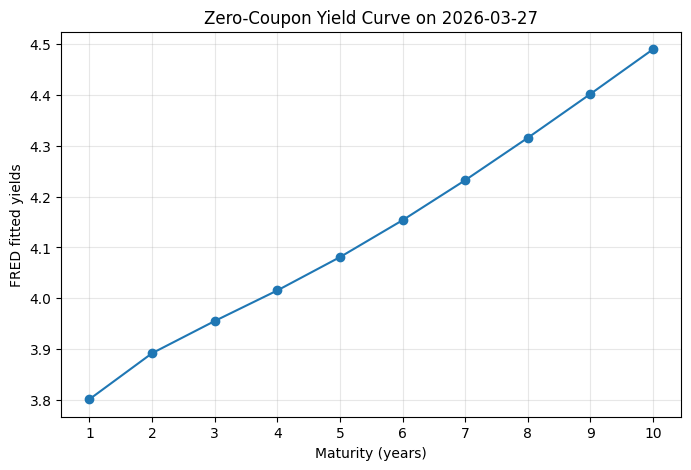

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact


# --- Edit these for "today" or another observation date ---
AS_OF_DATE = "2026-03-27"

# Maturities in years (table: 1Y–10Y)
maturity_years = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)

# Yields in percent (2026-03-27)
yields_pct = np.array([
    3.8014, 3.8919, 3.9552, 4.0154, 4.0809,
    4.1535, 4.2322, 4.3156, 4.4019, 4.4898,
])

# Plot todays yield curve
plt.figure(figsize=(8, 5))
plt.plot(maturity_years, yields_pct, marker='o')
plt.xlabel("Maturity (years)")
plt.ylabel("FRED fitted yields")
plt.title(f"Zero-Coupon Yield Curve on {AS_OF_DATE}")
plt.xticks(maturity_years)
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
import numpy as np

# =========================
# Configurable parameters
# =========================

# Pricing date (usually t = 0 for "today")
t = 0.0

# Current short rate r_t
r_t = 0.04

# CIR parameters under P
kappa_p = 0.60 # speed of returning to theta q (mean)
theta_p = 0.05 # the mean that the rate moves towards under Q
sigma = 0.10

# CIR parameters under Q
theta_q = 0.04 # the mean that 
kappa_q = kappa_p*theta_p/theta_q # kappa_q is not configurable, 
# its derived from other parameters to ensure we are in the case where the market price does not have a singularity
# and feller and novikov are always met


In [45]:
# P (t,T) = exp(a(t,T) - bt,T) r_) is the end goal

# construct b coefficient 
def b_cir(t, T, kappa_q, sigma):
    gamma = np.sqrt(kappa_q**2 + 2 * sigma**2)
    tau = T - t
    exp_gamma_tao_minus1 = (np.exp(gamma * tau) - 1)
    numerator = 2 * exp_gamma_tao_minus1
    denominator = (gamma + kappa_q) * exp_gamma_tao_minus1 + 2 * gamma
    return numerator / denominator

# construct a coefficient
def a_cir(t, T, kappa_q, theta_q, sigma):
    gamma = np.sqrt(kappa_q**2 + 2 * sigma**2)
    tau = T - t
    # print(f"Maturity: {T}, Kappa_q: {kappa_q}, Gamma: {gamma}")
    exp_gamma_tao_minus1 = (np.exp(gamma * tau) - 1)
    numerator = 2 * gamma * np.exp((kappa_q + gamma) * tau / 2)
    denominator = (gamma + kappa_q) * exp_gamma_tao_minus1 + 2 * gamma
    return (2 * kappa_q * theta_q / sigma**2) * np.log(numerator / denominator)

# def p_cir(t, T, r_t, kappa_q, theta_q, sigma):
#     a = a_cir(t, T, kappa_q, theta_q, sigma)
#     b = b_cir(t, T, kappa_q, sigma)
#     return np.exp(a - b * r_t)

def cir_yield(t, T, r_0, kappa_q, theta_q, sigma):
    a_coef = a_cir(t, T, kappa_q, theta_q, sigma)
    b_coef = b_cir(t, T, kappa_q, sigma)
    # print(f"Calculating yield for {T} maturity")
    # print(f"a_coef: {a_coef}")
    # print(f"b_coef: {b_coef}")
    cir_yield_pct = -100*(a_coef - b_coef*r_0)/(T-t) # divide by T to get the yield, because a(t,T) -b(t,T)r_0 is -yield*T
    return cir_yield_pct


# Plot todays yield curve and our price curve overlayed
def plot_cir_yield_curve(r_0, kappa_q, theta_q, sigma):
    yields_cir_model = []

    for T in maturity_years:
         # addition after trying to adjust for curvature
        kappa_q_T = kappa_q
        
        yield_T = cir_yield(0.0, T, r_0, kappa_q_T, theta_q, sigma)
        yields_cir_model.append(yield_T)

    plt.figure(figsize=(8, 5))
    plt.plot(maturity_years, yields_pct, marker='o', label='Fitted FRED yield curve(%)')
    plt.plot(maturity_years, yields_cir_model, marker='o', label='CIR yield estimates (%)')
    plt.xlabel("Maturity (years)")
    plt.ylabel("Yield ($)")
    plt.title(f"Zero-Coupon Yield Curve on {AS_OF_DATE}")
    plt.xticks(maturity_years)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

interact(
    plot_cir_yield_curve,
    r_0=widgets.FloatSlider(value=0.019, min=0.001, max=0.10, step=0.001, description='r_t'),
    kappa_q=widgets.FloatSlider(value=0.60, min=0.01, max=3.0, step=0.01, description='kappa_q'),
    theta_q=widgets.FloatSlider(value=0.05, min=0.001, max=0.15, step=0.001, description='theta_q'),
    sigma=widgets.FloatSlider(value=0.10, min=0.01, max=0.50, step=0.01, description='sigma')
)

# The reason we get a curve is because even though we have an affine yield * time model, which is on the Real numbers, when we log it 
# we get a curved function that looks like a log(x), or inverse exponential
# We like the endpoints but we dont like the curvature, the rate goes too high in the 2-9 year range. 

interactive(children=(FloatSlider(value=0.019, description='r_t', max=0.1, min=0.001, step=0.001), FloatSlider…

<function __main__.plot_cir_yield_curve(r_0, kappa_q, theta_q, sigma)>